In [1]:
# Step 1: Import required libraries
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

In [3]:
# Step 2: Load the pretrained YOLOv8 model (nano version for speed)
# This auto-downloads weights from Ultralytics Hub
model = YOLO("yolov3.pt")
print("✅ YOLOv3 model loaded successfully!")

PRO TIP  Replace 'model=yolov3.pt' with new 'model=yolov3u.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.



✅ YOLOv3 model loaded successfully!


In [4]:
# Step 3: Run object detection on a sample image
img_path = "https://ultralytics.com/images/bus.jpg"
results = model(img_path)


Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 C:\Users\Anand\Deep Learning\Lab Experiments\EX8-PERFORM_OBJECT_DETECTION_USING_YOLO\bus.jpg: 640x480 5 persons, 1 bus, 1 fire hydrant, 1104.7ms
Speed: 8.3ms preprocess, 1104.7ms inference, 10.5ms postprocess per image at shape (1, 3, 640, 480)


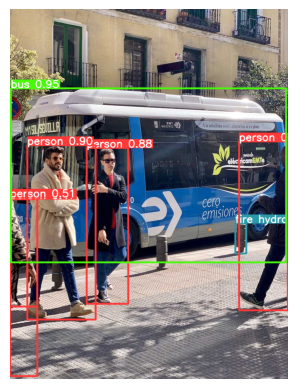

In [5]:
# Step 4: Display results

for r in results:
    annotated_img = r.plot()   # returns an annotated numpy array (BGR)
    
    # Save the annotated image
    cv2.imwrite("output.jpg", annotated_img)

    # Show inline (Jupyter / Colab)
    plt.imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

In [6]:
# Step 5: Print detected objects
for r in results:
    for box, cls, conf in zip(r.boxes.xyxy, r.boxes.cls, r.boxes.conf):
        print(f"Detected {model.names[int(cls)]} with confidence {conf:.2f}")


Detected bus with confidence 0.95
Detected person with confidence 0.92
Detected person with confidence 0.90
Detected person with confidence 0.88
Detected person with confidence 0.51
Detected person with confidence 0.47
Detected fire hydrant with confidence 0.29


In [7]:
# Step 6: (Optional) Run on webcam
# Uncomment to try
cap = cv2.VideoCapture(0)  # open webcam
while True:
    ret, frame = cap.read()
    if not ret:
        break
    results = model(frame)
    annotated_frame = results[0].plot()
    cv2.imshow("YOLOv8 Webcam Detection", annotated_frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()


0: 480x640 3 persons, 1067.4ms
Speed: 2.3ms preprocess, 1067.4ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 3 persons, 1052.2ms
Speed: 3.0ms preprocess, 1052.2ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 3 persons, 1026.9ms
Speed: 1.0ms preprocess, 1026.9ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 3 persons, 1006.6ms
Speed: 2.0ms preprocess, 1006.6ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 3 persons, 1005.9ms
Speed: 2.0ms preprocess, 1005.9ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 3 persons, 999.5ms
Speed: 1.5ms preprocess, 999.5ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 3 persons, 1015.5ms
Speed: 1.0ms preprocess, 1015.5ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 3 persons, 1023.0ms
Speed: 2.0ms preprocess, 1023.0ms inference, 0.0ms po